# Prediksi Penjualan Toko Ritel Rossman
**Kelompok 1 - LM01**  
Louis Huang | Gilbert Tjandra Adanarianto | Dava Rabbani Adrian Widyatmoko

**Tujuan:** Membangun model Machine Learning berbasis regresi untuk memprediksi jumlah penjualan toko ritel harian berdasarkan faktor promosi, hari libur, dan kondisi operasional.

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded successfully!')

Libraries loaded successfully!


In [2]:
train_df = pd.read_csv('./train.csv', low_memory=False)
store_df = pd.read_csv('./store.csv')

print('Train shape:', train_df.shape)
print('Store shape:', store_df.shape)
train_df.head()

Train shape: (1017209, 9)
Store shape: (1115, 10)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [3]:
store_df.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

In [4]:
print('=== Train Dataset Info ===')
train_df.info()
print()
print('=== Missing Values - Train ===')
print(train_df.isnull().sum())

=== Train Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype
---  ------         --------------    -----
 0   Store          1017209 non-null  int64
 1   DayOfWeek      1017209 non-null  int64
 2   Date           1017209 non-null  str  
 3   Sales          1017209 non-null  int64
 4   Customers      1017209 non-null  int64
 5   Open           1017209 non-null  int64
 6   Promo          1017209 non-null  int64
 7   StateHoliday   1017209 non-null  str  
 8   SchoolHoliday  1017209 non-null  int64
dtypes: int64(7), str(2)
memory usage: 80.5 MB

=== Missing Values - Train ===
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64


In [5]:
print('=== Store Dataset Info ===')
store_df.info()
print()
print('=== Missing Values - Store ===')
print(store_df.isnull().sum())

=== Store Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 98.0 KB

=== Missing Values - Store ===
Store                          0
StoreType                      0
Assortment                     0
CompetitionDist

In [6]:
train_df.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


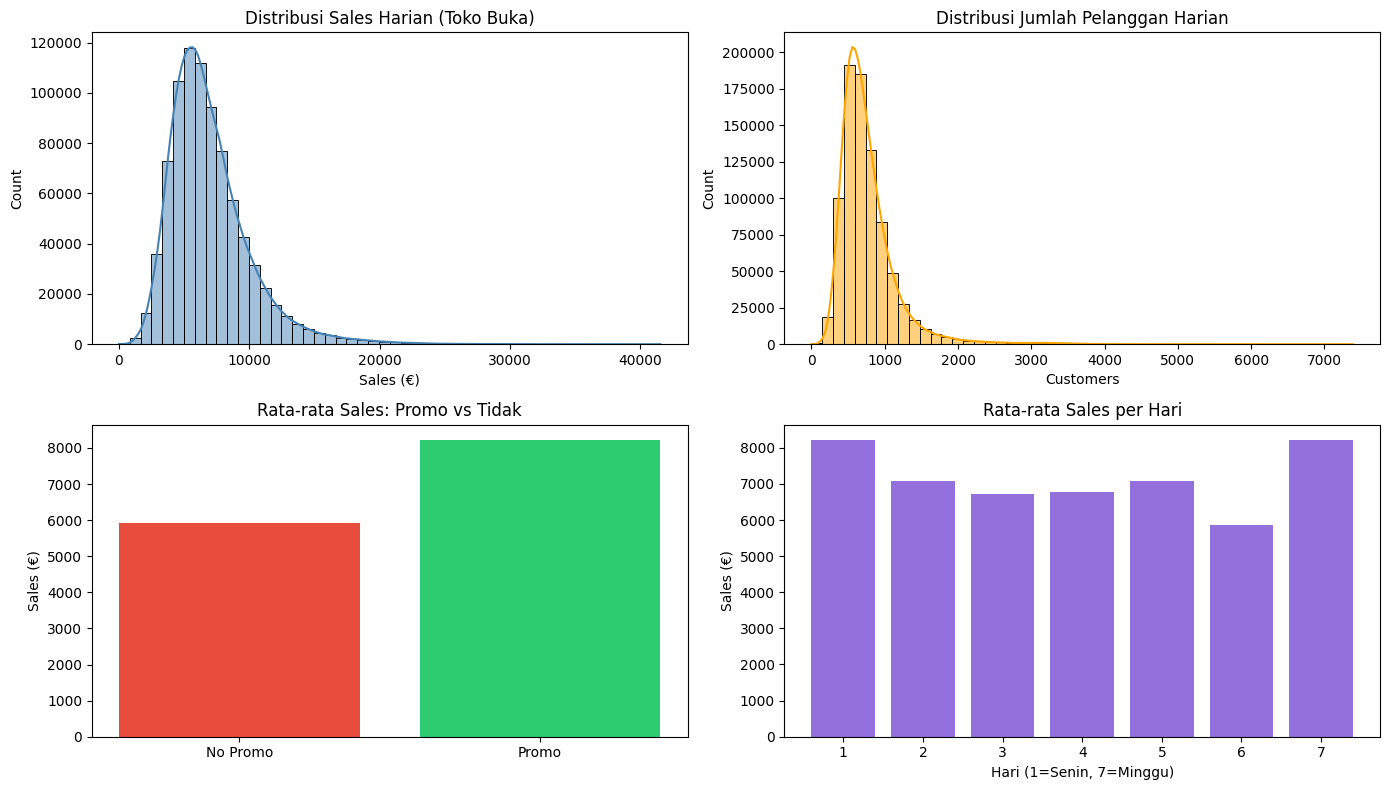

In [7]:
# Distribusi Sales dan variabel numerik utama
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Filter hanya toko buka
open_df = train_df[train_df['Open'] == 1]

sns.histplot(open_df['Sales'], bins=50, kde=True, ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Distribusi Sales Harian (Toko Buka)')
axes[0][0].set_xlabel('Sales (€)')

sns.histplot(open_df['Customers'], bins=50, kde=True, ax=axes[0][1], color='orange')
axes[0][1].set_title('Distribusi Jumlah Pelanggan Harian')
axes[0][1].set_xlabel('Customers')

sales_by_promo = open_df.groupby('Promo')['Sales'].mean().reset_index()
axes[1][0].bar(['No Promo', 'Promo'], sales_by_promo['Sales'], color=['#e74c3c', '#2ecc71'])
axes[1][0].set_title('Rata-rata Sales: Promo vs Tidak')
axes[1][0].set_ylabel('Sales (€)')

sales_by_dow = open_df.groupby('DayOfWeek')['Sales'].mean()
axes[1][1].bar(sales_by_dow.index, sales_by_dow.values, color='mediumpurple')
axes[1][1].set_title('Rata-rata Sales per Hari')
axes[1][1].set_xlabel('Hari (1=Senin, 7=Minggu)')
axes[1][1].set_ylabel('Sales (€)')

plt.tight_layout()
plt.show()

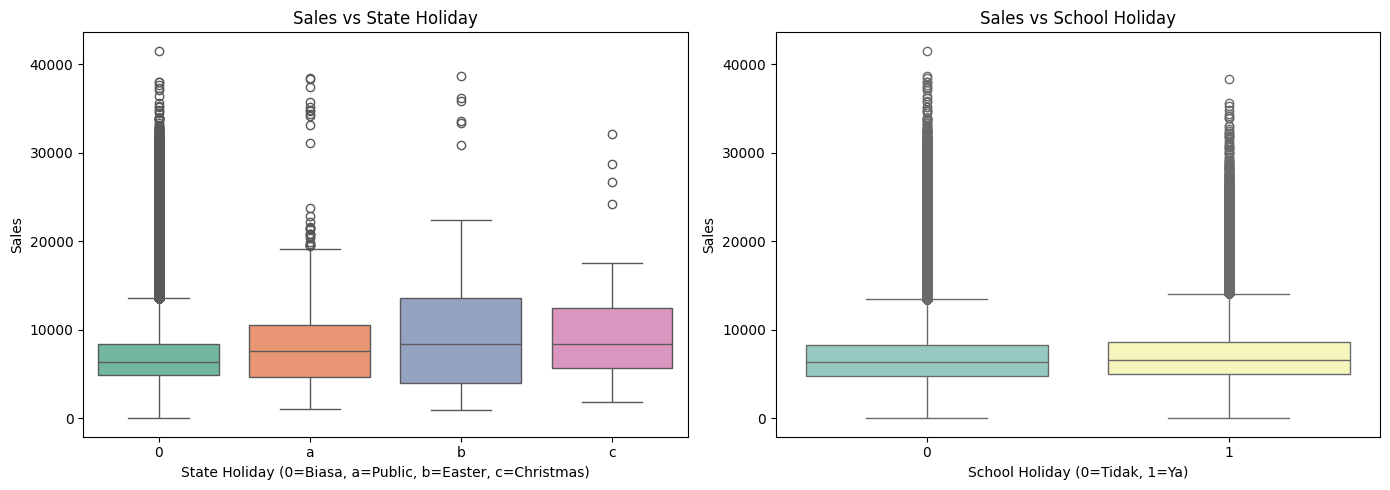

In [8]:
# Boxplot Sales berdasarkan State Holiday
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='StateHoliday', y='Sales', data=open_df, ax=axes[0], palette='Set2')
axes[0].set_title('Sales vs State Holiday')
axes[0].set_xlabel('State Holiday (0=Biasa, a=Public, b=Easter, c=Christmas)')

sns.boxplot(x='SchoolHoliday', y='Sales', data=open_df, ax=axes[1], palette='Set3')
axes[1].set_title('Sales vs School Holiday')
axes[1].set_xlabel('School Holiday (0=Tidak, 1=Ya)')

plt.tight_layout()
plt.show()

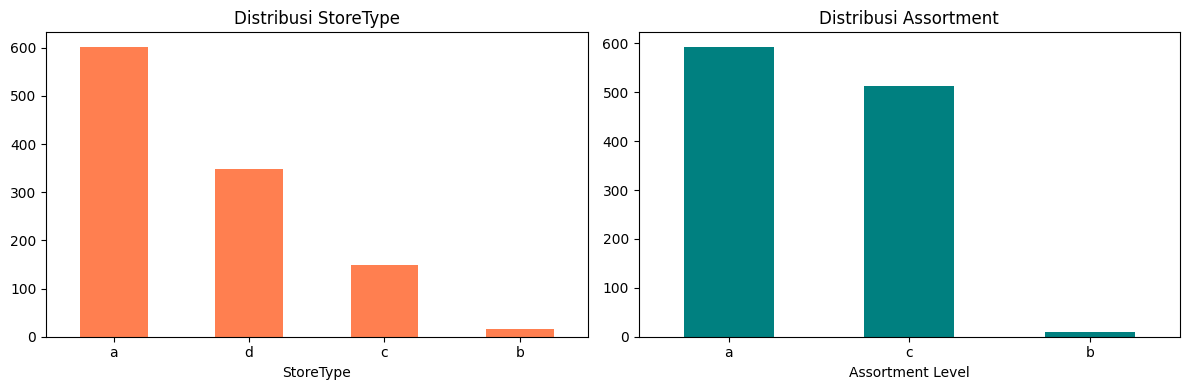

In [9]:
# Distribusi Store Types dan Assortment
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

store_df['StoreType'].value_counts().plot(kind='bar', ax=axes[0], color='coral', rot=0)
axes[0].set_title('Distribusi StoreType')
axes[0].set_xlabel('StoreType')

store_df['Assortment'].value_counts().plot(kind='bar', ax=axes[1], color='teal', rot=0)
axes[1].set_title('Distribusi Assortment')
axes[1].set_xlabel('Assortment Level')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [10]:
# Merge train dengan store data
df = pd.merge(train_df, store_df, on='Store', how='left')
print('Merged shape:', df.shape)

# Filter: hapus toko yang tutup (Sales = 0 saat Open = 0 adalah bias)
df = df[(df['Open'] == 1) & (df['Sales'] > 0)]
print('After filtering closed stores:', df.shape)

Merged shape: (1017209, 18)
After filtering closed stores: (844338, 18)


In [11]:
# Parse tanggal dan buat fitur temporal
df['Date'] = pd.to_datetime(df['Date'])
df['Year']  = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day']   = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)

print('Fitur tanggal ditambahkan.')
df[['Date', 'Year', 'Month', 'Day', 'WeekOfYear']].head()

Fitur tanggal ditambahkan.


,Date,Year,Month,Day,WeekOfYear
0,2015-07-31,2015,7,31,31
1,2015-07-31,2015,7,31,31
2,2015-07-31,2015,7,31,31
3,2015-07-31,2015,7,31,31
4,2015-07-31,2015,7,31,31


In [12]:
# Handle missing values
# CompetitionDistance: isi dengan median
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())

# Promo2 related - isi 0 jika tidak ada
df['CompetitionOpenSinceMonth'] = df['CompetitionOpenSinceMonth'].fillna(0)
df['CompetitionOpenSinceYear']  = df['CompetitionOpenSinceYear'].fillna(0)
df['Promo2SinceWeek']  = df['Promo2SinceWeek'].fillna(0)
df['Promo2SinceYear']  = df['Promo2SinceYear'].fillna(0)
df['PromoInterval']    = df['PromoInterval'].fillna('None')

print('Missing values setelah treatment:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values setelah treatment:
Series([], dtype: int64)


In [13]:
# Encode StateHoliday (0/a/b/c -> 0/1/2/3)
holiday_map = {'0': 0, 0: 0, 'a': 1, 'b': 2, 'c': 3}
df['StateHoliday'] = df['StateHoliday'].map(holiday_map).fillna(0).astype(int)

# Encode StoreType dan Assortment (label encode)
df['StoreType']   = df['StoreType'].map({'a': 0, 'b': 1, 'c': 2, 'd': 3}).fillna(0).astype(int)
df['Assortment']  = df['Assortment'].map({'a': 0, 'b': 1, 'c': 2}).fillna(0).astype(int)

# Encode PromoInterval
promo_map = {'None': 0, 'Jan,Apr,Jul,Oct': 1, 'Feb,May,Aug,Nov': 2, 'Mar,Jun,Sept,Dec': 3}
df['PromoInterval'] = df['PromoInterval'].map(promo_map).fillna(0).astype(int)

print('Encoding selesai.')

Encoding selesai.


In [14]:
# Pilih fitur yang digunakan untuk model
FEATURES = [
    'Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
    'StoreType', 'Assortment', 'CompetitionDistance',
    'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear',
    'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval',
    'Year', 'Month', 'Day', 'WeekOfYear'
]

TARGET = 'Sales'

X = df[FEATURES]
y = np.log1p(df[TARGET])  # log transform untuk normalisasi distribusi Sales

print('Shape X:', X.shape)
print('Sample X:')
X.head()

Shape X: (844338, 18)
Sample X:


,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day,WeekOfYear
0,1,5,1,0,1,2,0,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,31,31
1,2,5,1,0,1,0,0,570.0,11.0,2007.0,1,13.0,2010.0,1,2015,7,31,31
2,3,5,1,0,1,0,0,14130.0,12.0,2006.0,1,14.0,2011.0,1,2015,7,31,31
3,4,5,1,0,1,2,2,620.0,9.0,2009.0,0,0.0,0.0,0,2015,7,31,31
4,5,5,1,0,1,0,0,29910.0,4.0,2015.0,0,0.0,0.0,0,2015,7,31,31


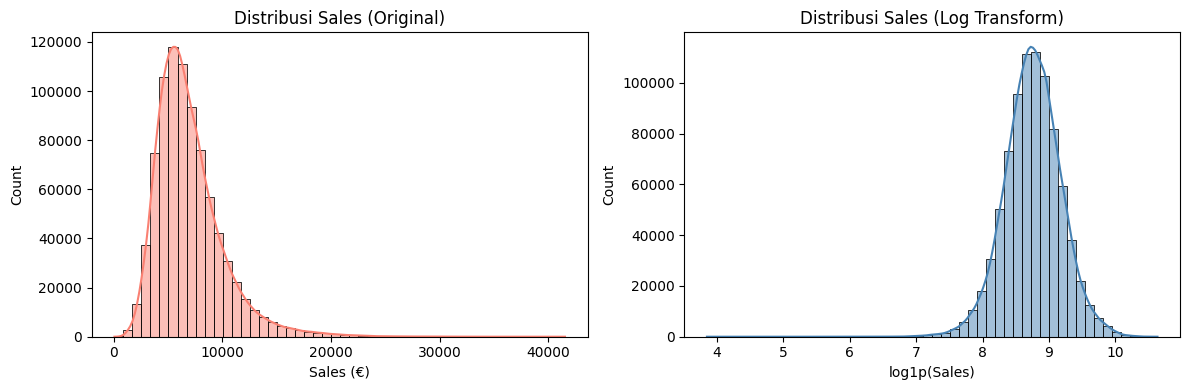

In [15]:
# Visualisasi distribusi Sales sebelum dan sesudah log transform
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df[TARGET], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].set_title('Distribusi Sales (Original)')
axes[0].set_xlabel('Sales (€)')

sns.histplot(y, bins=50, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Distribusi Sales (Log Transform)')
axes[1].set_xlabel('log1p(Sales)')

plt.tight_layout()
plt.show()

## 5. Pembagian Data (80:20)

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set  : {X_train.shape[0]:,} baris')
print(f'Test set      : {X_test.shape[0]:,} baris')

Training set  : 675,470 baris
Test set      : 168,868 baris


## 6. Pelatihan Model

### 6a. Baseline: Linear Regression

In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print('Linear Regression selesai dilatih.')

Linear Regression selesai dilatih.


### 6b. Model Utama: Random Forest Regressor

In [18]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)
print('Random Forest selesai dilatih.')

Random Forest selesai dilatih.


### 6c. Model Pembanding: XGBoost Regressor

In [19]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=7,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)
xgb_model.fit(X_train, y_train)
print('XGBoost selesai dilatih.')

XGBoost selesai dilatih.


## 7. Evaluasi Model

In [20]:
def evaluate_model(name, model, X_test, y_test):
    y_pred_log = model.predict(X_test)
    
    # Kembalikan ke skala Sales asli
    y_test_real = np.expm1(y_test)
    y_pred_real = np.expm1(y_pred_log)
    
    mae  = mean_absolute_error(y_test_real, y_pred_real)
    mse  = mean_squared_error(y_test_real, y_pred_real)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test_real, y_pred_real)
    
    mean_sales = np.mean(y_test_real)
    mae_pct  = (mae  / mean_sales) * 100
    rmse_pct = (rmse / mean_sales) * 100
    
    print(f'--- {name} ---')
    print(f'MAE  : €{mae:,.2f}  (~{mae_pct:.2f}% dari rata-rata sales)')
    print(f'RMSE : €{rmse:,.2f} (~{rmse_pct:.2f}% dari rata-rata sales)')
    print(f'R²   : {r2:.4f}')
    print()
    
    return {
        'name': name,
        'mae': mae, 'rmse': rmse, 'r2': r2,
        'mae_pct': mae_pct, 'rmse_pct': rmse_pct,
        'y_aktual': y_test_real.values if hasattr(y_test_real, 'values') else np.array(y_test_real),
        'y_prediksi': y_pred_real
    }

lr_eval  = evaluate_model('Linear Regression', lr_model,  X_test, y_test)
rf_eval  = evaluate_model('Random Forest',     rf_model,  X_test, y_test)
xgb_eval = evaluate_model('XGBoost',           xgb_model, X_test, y_test)

--- Linear Regression ---
MAE  : €1,979.31  (~28.44% dari rata-rata sales)
RMSE : €2,830.29 (~40.67% dari rata-rata sales)
R²   : 0.1699

--- Random Forest ---
MAE  : €1,061.17  (~15.25% dari rata-rata sales)
RMSE : €1,572.50 (~22.60% dari rata-rata sales)
R²   : 0.7437

--- XGBoost ---
MAE  : €917.41  (~13.18% dari rata-rata sales)
RMSE : €1,336.84 (~19.21% dari rata-rata sales)
R²   : 0.8148



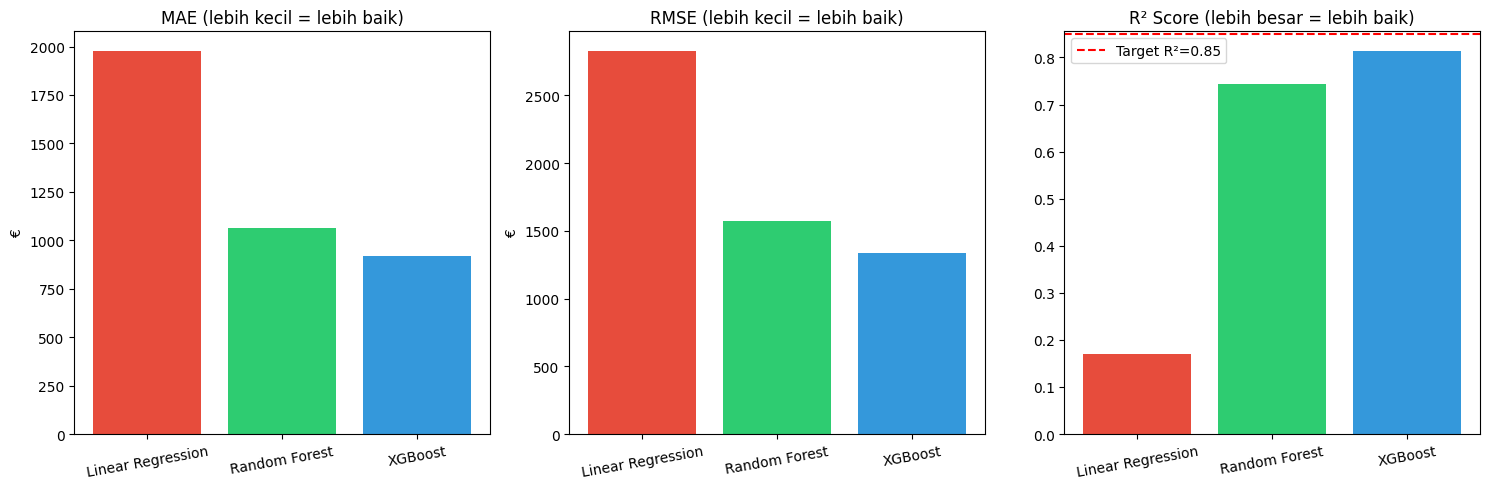

In [21]:
# Visualisasi perbandingan metrik
models_list = ['Linear Regression', 'Random Forest', 'XGBoost']
mae_vals  = [lr_eval['mae'],      rf_eval['mae'],      xgb_eval['mae']]
rmse_vals = [lr_eval['rmse'],     rf_eval['rmse'],     xgb_eval['rmse']]
r2_vals   = [lr_eval['r2'],       rf_eval['r2'],       xgb_eval['r2']]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['#e74c3c', '#2ecc71', '#3498db']

axes[0].bar(models_list, mae_vals,  color=colors)
axes[0].set_title('MAE (lebih kecil = lebih baik)')
axes[0].set_ylabel('€')
axes[0].tick_params(axis='x', rotation=10)

axes[1].bar(models_list, rmse_vals, color=colors)
axes[1].set_title('RMSE (lebih kecil = lebih baik)')
axes[1].set_ylabel('€')
axes[1].tick_params(axis='x', rotation=10)

axes[2].bar(models_list, r2_vals,   color=colors)
axes[2].set_title('R² Score (lebih besar = lebih baik)')
axes[2].axhline(y=0.85, color='red', linestyle='--', label='Target R²=0.85')
axes[2].legend()
axes[2].tick_params(axis='x', rotation=10)

plt.tight_layout()
plt.show()

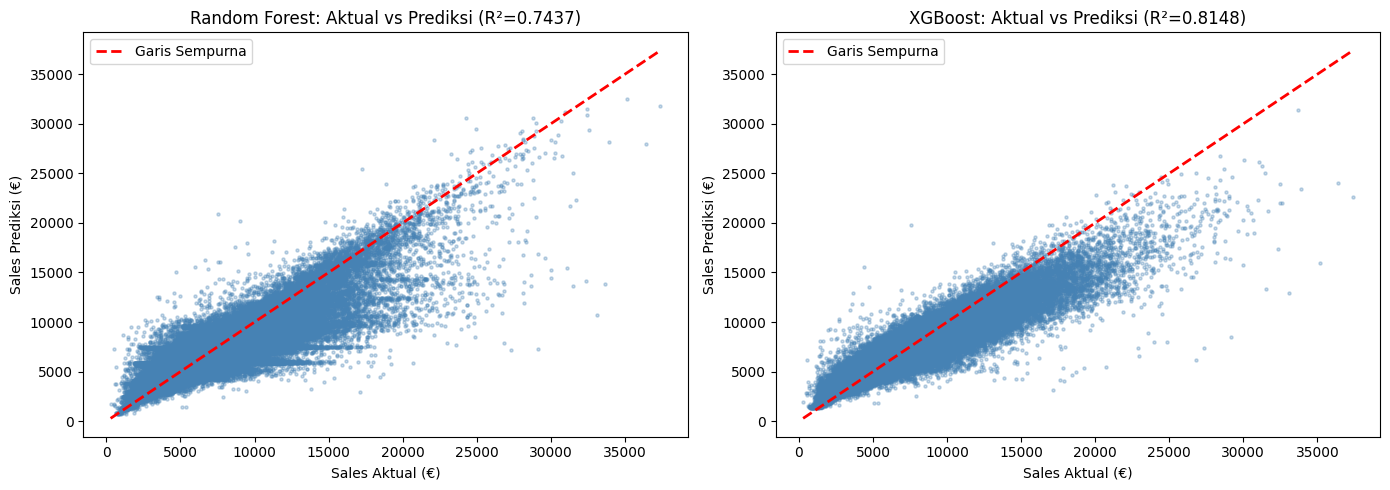

In [22]:
# Scatter plot: Aktual vs Prediksi untuk model terbaik (RF)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, eval_data, title in zip(axes, [rf_eval, xgb_eval], ['Random Forest', 'XGBoost']):
    ax.scatter(eval_data['y_aktual'], eval_data['y_prediksi'], alpha=0.3, s=5, color='steelblue')
    min_val = min(eval_data['y_aktual'].min(), eval_data['y_prediksi'].min())
    max_val = max(eval_data['y_aktual'].max(), eval_data['y_prediksi'].max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Garis Sempurna')
    ax.set_xlabel('Sales Aktual (€)')
    ax.set_ylabel('Sales Prediksi (€)')
    ax.set_title(f'{title}: Aktual vs Prediksi (R²={eval_data["r2"]:.4f})')
    ax.legend()

plt.tight_layout()
plt.show()

## 8. Feature Importance

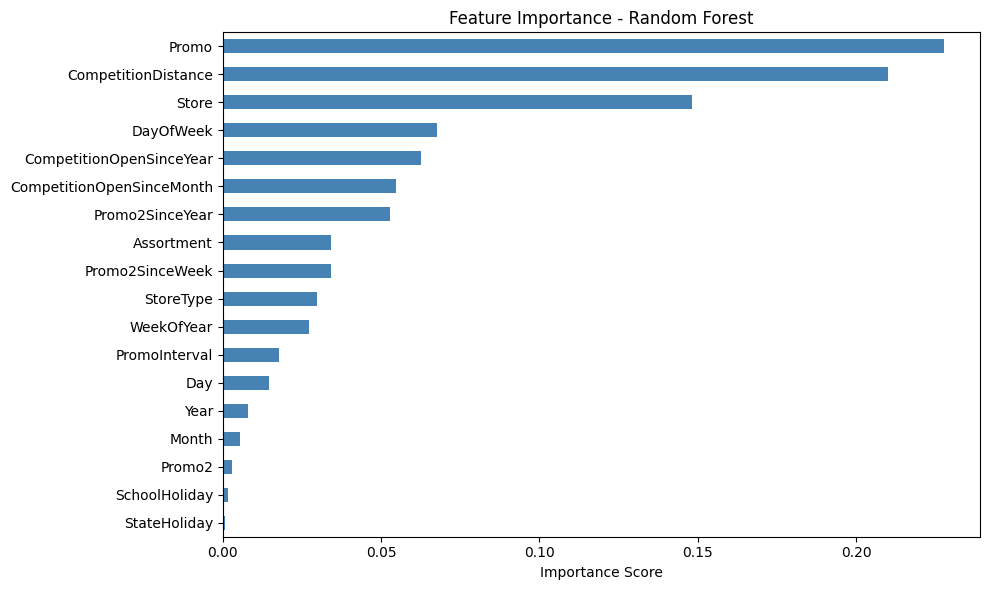

Top 5 Fitur Paling Berpengaruh:
Promo                       0.227738
CompetitionDistance         0.210034
Store                       0.148045
DayOfWeek                   0.067636
CompetitionOpenSinceYear    0.062505
dtype: float64


In [23]:
# Feature Importance dari Random Forest
feat_imp = pd.Series(rf_model.feature_importances_, index=FEATURES)
feat_imp = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feat_imp.plot(kind='barh', color='steelblue')
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('Top 5 Fitur Paling Berpengaruh:')
print(feat_imp.head(5))

## 9. Hyperparameter Tuning (RandomizedSearchCV) pada Model Terbaik

In [24]:
# Tentukan model terbaik berdasarkan R²
best_r2 = max(rf_eval['r2'], xgb_eval['r2'])
best_name = 'Random Forest' if rf_eval['r2'] >= xgb_eval['r2'] else 'XGBoost'
print(f'Model terbaik untuk tuning: {best_name} (R²={best_r2:.4f})')

Model terbaik untuk tuning: XGBoost (R²=0.8148)


In [25]:
# Hyperparameter Tuning pada sebagian data agar lebih cepat
sample_size = min(50000, len(X_train))
idx = np.random.choice(len(X_train), sample_size, replace=False)
X_train_sample = X_train.iloc[idx]
y_train_sample = y_train.iloc[idx]

if best_name == 'Random Forest':
    param_grid = {
        'n_estimators':     [100, 200, 300],
        'max_depth':        [10, 15, 20, None],
        'min_samples_split':[2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestRegressor(n_jobs=-1, random_state=42)
else:
    param_grid = {
        'n_estimators':   [200, 300, 500],
        'learning_rate':  [0.01, 0.05, 0.1],
        'max_depth':      [5, 7, 9],
        'subsample':      [0.7, 0.8, 0.9]
    }
    base_model = XGBRegressor(n_jobs=-1, random_state=42, verbosity=0)

tuner = RandomizedSearchCV(
    base_model,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

tuner.fit(X_train_sample, y_train_sample)
print('Best params:', tuner.best_params_)
print(f'Best CV R²: {tuner.best_score_:.4f}')

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params: {'subsample': 0.8, 'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.1}
Best CV R²: 0.8956


In [26]:
# Latih model final dengan best params pada seluruh data training
best_model = tuner.best_estimator_.__class__(**tuner.best_params_, n_jobs=-1, random_state=42)
best_model.fit(X_train, y_train)

tuned_eval = evaluate_model(f'{best_name} (Tuned)', best_model, X_test, y_test)

print('\nPerbandingan sebelum dan sesudah tuning:')
if best_name == 'Random Forest':
    base_eval = rf_eval
else:
    base_eval = xgb_eval

print(f'Sebelum - R²: {base_eval["r2"]:.4f}, MAE: €{base_eval["mae"]:,.0f}')
print(f'Sesudah - R²: {tuned_eval["r2"]:.4f}, MAE: €{tuned_eval["mae"]:,.0f}')

--- XGBoost (Tuned) ---
MAE  : €548.98  (~7.89% dari rata-rata sales)
RMSE : €801.19 (~11.51% dari rata-rata sales)
R²   : 0.9335


Perbandingan sebelum dan sesudah tuning:
Sebelum - R²: 0.8148, MAE: €917
Sesudah - R²: 0.9335, MAE: €549


## 10. Simpan Model & Artefak

In [27]:
# Pilih model terbaik setelah tuning
final_model = best_model
final_eval  = tuned_eval

# Simpan artefak
joblib.dump(final_model,  'model_rossman.pkl')
joblib.dump(FEATURES,     'model_features.pkl')

# Simpan feature importance untuk visualisasi di app
if hasattr(final_model, 'feature_importances_'):
    feat_imp_dict = dict(zip(FEATURES, final_model.feature_importances_))
    feat_imp_sorted = dict(sorted(feat_imp_dict.items(), key=lambda x: x[1], reverse=True))
else:
    feat_imp_sorted = {}
joblib.dump(feat_imp_sorted, 'feature_importance.pkl')

# Simpan eval data
eval_package = {
    'y_aktual':   final_eval['y_aktual'],
    'y_prediksi': final_eval['y_prediksi'],
    'mae':        final_eval['mae'],
    'rmse':       final_eval['rmse'],
    'r2':         final_eval['r2'],
    'mae_pct':    final_eval['mae_pct'],
    'rmse_pct':   final_eval['rmse_pct'],
    'model_name': f"{best_name} (Tuned)"
}
joblib.dump(eval_package, 'eval_data.pkl')

print('Model dan artefak berhasil disimpan!')
print('   - model_rossman.pkl')
print('   - model_features.pkl')
print('   - feature_importance.pkl')
print('   - eval_data.pkl')

Model dan artefak berhasil disimpan!
   - model_rossman.pkl
   - model_features.pkl
   - feature_importance.pkl
   - eval_data.pkl
